In [1]:
# Machine Learning for Genomic Data
# Random Forest Classification

import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create sample genomic dataset
data = {
    "TP53":  [8.2, 7.9, 8.5, 8.0, 7.6, 3.2, 3.5, 2.9, 3.7, 3.1, 3.8, 3.3],
    "BRCA1": [7.8, 8.1, 7.5, 8.3, 7.9, 4.1, 4.4, 3.8, 4.5, 4.0, 4.3, 4.2],
    "EGFR":  [3.1, 3.5, 3.2, 3.8, 4.0, 9.1, 8.7, 9.4, 8.9, 9.2, 8.5, 9.0],
    "MYC":   [4.2, 4.5, 4.0, 4.7, 4.3, 8.5, 8.9, 9.1, 8.2, 8.7, 8.4, 8.8],
    "PTEN":  [8.5, 8.2, 8.8, 8.0, 8.4, 2.8, 3.1, 2.5, 3.4, 2.7, 3.0, 2.9],
    "Class": [
        "Normal", "Normal", "Normal", "Normal", "Normal",
        "Cancer", "Cancer", "Cancer", "Cancer",
        "Cancer", "Cancer", "Cancer"
    ]
}

# Create DataFrame
df = pd.DataFrame(data)

print("Genomic Dataset:")
print(df)

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Feature importance
importance = pd.DataFrame({
    "Gene": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

Genomic Dataset:
    TP53  BRCA1  EGFR  MYC  PTEN   Class
0    8.2    7.8   3.1  4.2   8.5  Normal
1    7.9    8.1   3.5  4.5   8.2  Normal
2    8.5    7.5   3.2  4.0   8.8  Normal
3    8.0    8.3   3.8  4.7   8.0  Normal
4    7.6    7.9   4.0  4.3   8.4  Normal
5    3.2    4.1   9.1  8.5   2.8  Cancer
6    3.5    4.4   8.7  8.9   3.1  Cancer
7    2.9    3.8   9.4  9.1   2.5  Cancer
8    3.7    4.5   8.9  8.2   3.4  Cancer
9    3.1    4.0   9.2  8.7   2.7  Cancer
10   3.8    4.3   8.5  8.4   3.0  Cancer
11   3.3    4.2   9.0  8.8   2.9  Cancer

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

      Cancer       1.00      1.00      1.00         2
      Normal       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3


Confusion Matrix:
[[2 0]
 [0 1]]

Feature Importance:
    Gene  Importance
3    MYC

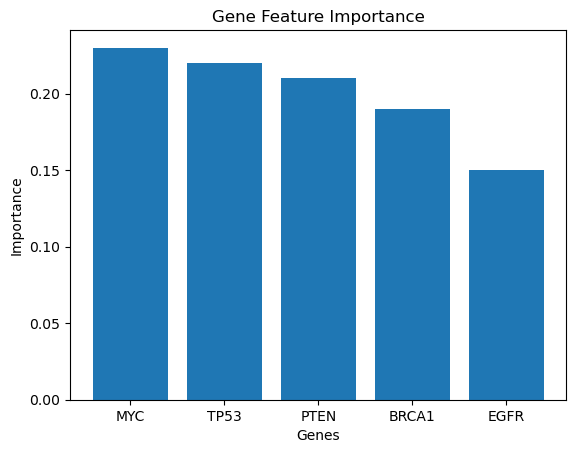

In [2]:
import matplotlib.pyplot as plt

plt.bar(
    importance["Gene"],
    importance["Importance"]
)

plt.xlabel("Genes")
plt.ylabel("Importance")
plt.title("Gene Feature Importance")

plt.show()